In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# =================================================================
# 0. CONFIGURAÇÃO DA GPU E SEMENTE (Para evitar travamentos)
# =================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Processando na: {device}")

# =================================================================
# PILAR 1: O MEGAZORD DE DADOS (Desde 2019)
# =================================================================
print("📥 Baixando dados completos do mercado...")
tickers = ['MSFT', 'GOOGL', 'NVDA', 'META', '^GSPC', '^VIX']
dados = yf.download(tickers, start="2019-01-01", end="2026-01-01")

df = pd.DataFrame()

# 17 Features no total
df['MSFT_Close']  = dados['Close']['MSFT']
df['MSFT_Open']   = dados['Open']['MSFT']
df['MSFT_High']   = dados['High']['MSFT']
df['MSFT_Low']    = dados['Low']['MSFT']
df['MSFT_Volume'] = dados['Volume']['MSFT']
df['GOOGL_Close'] = dados['Close']['GOOGL']
df['NVDA_Close']  = dados['Close']['NVDA']
df['META_Close']  = dados['Close']['META']
df['SP500_Close'] = dados['Close']['^GSPC']
df['VIX_Close']   = dados['Close']['^VIX']

# Indicadores
df['MSFT_SMA_20'] = df['MSFT_Close'].rolling(window=20).mean()
df['MSFT_EMA_20'] = df['MSFT_Close'].ewm(span=20, adjust=False).mean()

delta = df['MSFT_Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['MSFT_RSI_14'] = 100 - (100 / (1 + rs))

exp1 = df['MSFT_Close'].ewm(span=12, adjust=False).mean()
exp2 = df['MSFT_Close'].ewm(span=26, adjust=False).mean()
df['MSFT_MACD'] = exp1 - exp2
df['MSFT_MACD_Signal'] = df['MSFT_MACD'].ewm(span=9, adjust=False).mean()

std_20 = df['MSFT_Close'].rolling(window=20).std()
df['MSFT_BB_Upper'] = df['MSFT_SMA_20'] + (std_20 * 2)
df['MSFT_BB_Lower'] = df['MSFT_SMA_20'] - (std_20 * 2)

df = df.dropna()
QTD_FEATURES = len(df.columns) # Vai dar 17

# Normalização
scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(df)

def criar_sequencias(dados_array, seq_len):
    X, y = [], []
    for i in range(seq_len, len(dados_array)):
        X.append(dados_array[i-seq_len:i])
        y.append(dados_array[i, 0]) 
    return np.array(X), np.array(y)

seq_len = 60
X, y = criar_sequencias(dados_normalizados, seq_len)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=32)

matriz_falsa_reais = np.zeros((len(y_test), QTD_FEATURES))
matriz_falsa_reais[:, 0] = y_test
reais_em_dolar = scaler.inverse_transform(matriz_falsa_reais)[:, 0]

# =================================================================
# PILAR 2: A MÁQUINA
# =================================================================
class Modelo_Hibrido_IA(nn.Module):
    def __init__(self, input_size, hidden_lstm, hidden_gru, output_size):
        super(Modelo_Hibrido_IA, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_lstm, batch_first=True)
        self.gru = nn.GRU(hidden_lstm, hidden_gru, batch_first=True)
        self.fc = nn.Linear(hidden_gru, output_size)

    def forward(self, x):
        saida_lstm, _ = self.lstm(x)
        saida_gru, _ = self.gru(saida_lstm)
        out_ultimo_dia = saida_gru[:, -1, :]
        previsao = self.fc(out_ultimo_dia)
        return previsao

# =================================================================
# PILARES 3 a 5: MEGA TESTE
# =================================================================
N_RODADAS = 100 
epocas_por_rodada = 50

todas_previsoes_teste = []
todas_previsoes_futuro = []

print(f"\n🚀 Iniciando {N_RODADAS} modelos com {QTD_FEATURES} variáveis...")

for rodada in range(N_RODADAS):
    # input_size travado na variável QTD_FEATURES (17)
    modelo_ensemble = Modelo_Hibrido_IA(input_size=QTD_FEATURES, hidden_lstm=64, hidden_gru=32, output_size=1).to(device)
    optimizer = optim.Adam(modelo_ensemble.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    modelo_ensemble.train()
    for epoca in range(epocas_por_rodada):
        for pacotes_X, pacotes_y in train_loader:
            pacotes_X, pacotes_y = pacotes_X.to(device), pacotes_y.to(device)
            optimizer.zero_grad()
            previsoes = modelo_ensemble(pacotes_X).squeeze()
            erro = criterion(previsoes, pacotes_y)
            erro.backward()
            optimizer.step()
            
    modelo_ensemble.eval()
    previsoes_modelo = []
    with torch.no_grad():
        for pacotes_X, pacotes_y in test_loader:
            pacotes_X = pacotes_X.to(device)
            chute = modelo_ensemble(pacotes_X)
            previsoes_modelo.extend(chute.cpu().squeeze().tolist())
            
    tensor_janela = torch.tensor(dados_normalizados[-60:], dtype=torch.float32).unsqueeze(0)
    previsoes_futuras_normalizadas = []
    with torch.no_grad():
        for i in range(7):
            previsao_msft = modelo_ensemble(tensor_janela.to(device))
            valor_previsto = previsao_msft.cpu().item()
            previsoes_futuras_normalizadas.append(valor_previsto)
            
            novo_dia = tensor_janela[:, -1, :].clone()
            novo_dia[0, 0] = valor_previsto 
            novo_dia = novo_dia.unsqueeze(1)
            tensor_janela = torch.cat((tensor_janela[:, 1:, :], novo_dia), dim=1)

    matriz_teste = np.zeros((len(previsoes_modelo), QTD_FEATURES))
    matriz_teste[:, 0] = previsoes_modelo
    todas_previsoes_teste.append(scaler.inverse_transform(matriz_teste)[:, 0])
    
    matriz_futuro = np.zeros((7, QTD_FEATURES))
    matriz_futuro[:, 0] = previsoes_futuras_normalizadas
    todas_previsoes_futuro.append(scaler.inverse_transform(matriz_futuro)[:, 0])
    
    if (rodada + 1) % 10 == 0:
        print(f"✅ Rodada {rodada+1}/{N_RODADAS} concluída.")

media_previsoes_teste = np.mean(todas_previsoes_teste, axis=0)
media_previsoes_futuro = np.mean(todas_previsoes_futuro, axis=0)

mae_final = mean_absolute_error(reais_em_dolar, media_previsoes_teste)
rmse_final = np.sqrt(mean_squared_error(reais_em_dolar, media_previsoes_teste))
mape_final = np.mean(np.abs((reais_em_dolar - media_previsoes_teste) / (reais_em_dolar + 1e-8))) * 100

print("\n" + "="*50)
print(f"🏆 BASELINE MEGAZORD: 17 FEATURES (Desde 2019) 🏆")
print("="*50)
print(f"MAE  (Erro Médio Absoluto): US$ {mae_final:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): US$ {rmse_final:.2f}")
print(f"MAPE (Erro Percentual): {mape_final:.2f}%")
print("="*50)

🔥 Processando na: cuda
📥 Baixando dados completos do mercado...


[*********************100%***********************]  6 of 6 completed



🚀 Iniciando 100 modelos com 17 variáveis...
✅ Rodada 10/100 concluída.
✅ Rodada 20/100 concluída.
✅ Rodada 30/100 concluída.
✅ Rodada 40/100 concluída.
✅ Rodada 50/100 concluída.
✅ Rodada 60/100 concluída.
✅ Rodada 70/100 concluída.
✅ Rodada 80/100 concluída.
✅ Rodada 90/100 concluída.
✅ Rodada 100/100 concluída.

🏆 BASELINE MEGAZORD: 17 FEATURES (Desde 2019) 🏆
MAE  (Erro Médio Absoluto): US$ 8.34
RMSE (Raiz do Erro Quadrático): US$ 10.70
MAPE (Erro Percentual): 1.81%


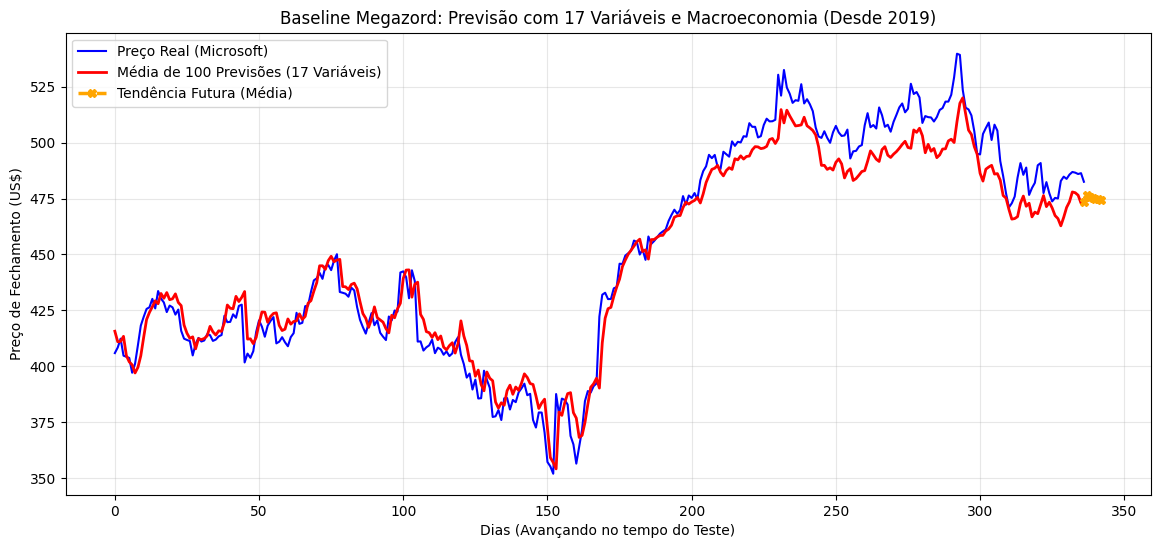


🔮 PREVISÃO FUTURA (7 DIAS) - MEGAZORD:
Dia 1: US$ 476.49
Dia 2: US$ 475.62
Dia 3: US$ 475.12
Dia 4: US$ 474.82
Dia 5: US$ 474.66
Dia 6: US$ 474.58
Dia 7: US$ 474.55


In [4]:
import matplotlib.pyplot as plt

# =================================================================
# GRÁFICO DO BASELINE (MEGAZORD)
# =================================================================
plt.figure(figsize=(14, 6))

# Plotando os dados de teste (Passado)
plt.plot(reais_em_dolar, label='Preço Real (Microsoft)', color='blue', linewidth=1.5)
plt.plot(media_previsoes_teste, label='Média de 100 Previsões (17 Variáveis)', color='red', linestyle='-', linewidth=2)

# Emendando a Previsão Futura
ultimo_dia_teste = len(reais_em_dolar) - 1
eixo_x_futuro = range(ultimo_dia_teste, ultimo_dia_teste + 7)
linha_futura_conectada = [media_previsoes_teste[-1]] + list(media_previsoes_futuro[:-1])

plt.plot(eixo_x_futuro, linha_futura_conectada, label='Tendência Futura (Média)', color='orange', linestyle='dashed', linewidth=2.5, marker='X')

# Configurações de exibição
plt.title('Baseline Megazord: Previsão com 17 Variáveis e Macroeconomia (Desde 2019)')
plt.xlabel('Dias (Avançando no tempo do Teste)')
plt.ylabel('Preço de Fechamento (US$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Imprimindo os valores da linha laranja
print("\n🔮 PREVISÃO FUTURA (7 DIAS) - MEGAZORD:")
for i, preco in enumerate(media_previsoes_futuro, 1):
    print(f"Dia {i}: US$ {preco:.2f}")

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# =================================================================
# 0. CONFIGURAÇÃO DA GPU E SEMENTE (Para evitar travamentos)
# =================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Processando na: {device}")

# =================================================================
# PILAR 1: O MEGAZORD DE DADOS (Desde 2019)
# =================================================================
print("📥 Baixando dados completos do mercado...")
tickers = ['MSFT', 'GOOGL', 'NVDA', 'META', '^GSPC', '^VIX']
dados = yf.download(tickers, start="2019-01-01", end="2026-01-01")

df = pd.DataFrame()

# 17 Features no total
df['MSFT_Close']  = dados['Close']['MSFT']
df['MSFT_Open']   = dados['Open']['MSFT']
df['MSFT_High']   = dados['High']['MSFT']
df['MSFT_Low']    = dados['Low']['MSFT']
df['MSFT_Volume'] = dados['Volume']['MSFT']
df['GOOGL_Close'] = dados['Close']['GOOGL']
df['NVDA_Close']  = dados['Close']['NVDA']
df['META_Close']  = dados['Close']['META']
df['SP500_Close'] = dados['Close']['^GSPC']
df['VIX_Close']   = dados['Close']['^VIX']

# Indicadores
df['MSFT_SMA_20'] = df['MSFT_Close'].rolling(window=20).mean()
df['MSFT_EMA_20'] = df['MSFT_Close'].ewm(span=20, adjust=False).mean()

delta = df['MSFT_Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['MSFT_RSI_14'] = 100 - (100 / (1 + rs))

exp1 = df['MSFT_Close'].ewm(span=12, adjust=False).mean()
exp2 = df['MSFT_Close'].ewm(span=26, adjust=False).mean()
df['MSFT_MACD'] = exp1 - exp2
df['MSFT_MACD_Signal'] = df['MSFT_MACD'].ewm(span=9, adjust=False).mean()

std_20 = df['MSFT_Close'].rolling(window=20).std()
df['MSFT_BB_Upper'] = df['MSFT_SMA_20'] + (std_20 * 2)
df['MSFT_BB_Lower'] = df['MSFT_SMA_20'] - (std_20 * 2)

df = df.dropna()
QTD_FEATURES = len(df.columns) # Vai dar 17

# Normalização
scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(df)

def criar_sequencias(dados_array, seq_len):
    X, y = [], []
    for i in range(seq_len, len(dados_array)):
        X.append(dados_array[i-seq_len:i])
        y.append(dados_array[i, 0]) 
    return np.array(X), np.array(y)

seq_len = 60
X, y = criar_sequencias(dados_normalizados, seq_len)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=32)

matriz_falsa_reais = np.zeros((len(y_test), QTD_FEATURES))
matriz_falsa_reais[:, 0] = y_test
reais_em_dolar = scaler.inverse_transform(matriz_falsa_reais)[:, 0]

# =================================================================
# PILAR 2: A MÁQUINA
# =================================================================
class Modelo_Hibrido_IA(nn.Module):
    def __init__(self, input_size, hidden_lstm, hidden_gru, output_size):
        super(Modelo_Hibrido_IA, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_lstm, batch_first=True)
        self.gru = nn.GRU(hidden_lstm, hidden_gru, batch_first=True)
        self.fc = nn.Linear(hidden_gru, output_size)

    def forward(self, x):
        saida_lstm, _ = self.lstm(x)
        saida_gru, _ = self.gru(saida_lstm)
        out_ultimo_dia = saida_gru[:, -1, :]
        previsao = self.fc(out_ultimo_dia)
        return previsao
import optuna

# =================================================================
# O CÉREBRO DO OPTUNA (Otimizando apenas a Arquitetura Vencedora)
# =================================================================
def objective(trial):
    # O Optuna vai buscar os neurônios ideais para o Modelo Cru
    hidden_lstm = trial.suggest_int('hidden_lstm', 16, 128, step=16)
    hidden_gru = trial.suggest_int('hidden_gru', 16, 128, step=16)
    
    # Limite seguro para a Taxa de Aprendizado (para evitar explosões)
    lr = trial.suggest_float('lr', 1e-4, 2e-3, log=True)
    
    # Usando EXATAMENTE a classe do seu modelo vencedor
    modelo = Modelo_Hibrido_IA(QTD_FEATURES, hidden_lstm, hidden_gru, 1).to(device)
    optimizer = optim.Adam(modelo.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Treinando por 50 ÉPOCAS (O mesmo do Mega Teste)
    modelo.train()
    for epoca in range(50):
        for pacotes_X, pacotes_y in train_loader:
            pacotes_X, pacotes_y = pacotes_X.to(device), pacotes_y.to(device)
            optimizer.zero_grad()
            previsoes = modelo(pacotes_X).squeeze()
            erro = criterion(previsoes, pacotes_y)
            erro.backward()
            optimizer.step()
            
    # Avaliando
    modelo.eval()
    erro_total = 0
    with torch.no_grad():
        for pacotes_X, pacotes_y in test_loader:
            pacotes_X, pacotes_y = pacotes_X.to(device), pacotes_y.to(device)
            chute = modelo(pacotes_X).squeeze()
            erro_teste = criterion(chute, pacotes_y)
            erro_total += erro_teste.item()
            
    return erro_total / len(test_loader)

print("\n🤖 Optuna: Otimizando os hiperparâmetros do Megazord Cru...")
study = optuna.create_study(direction="minimize")
# 30 tentativas para ter certeza absoluta da melhor configuração
study.optimize(objective, n_trials=30) 

print("\n" + "="*50)
print("🏆 A IA ESCOLHEU OS PARÂMETROS PARA O MODELO CRU:")
print("="*50)
print(f"Neurônios na LSTM: {study.best_params['hidden_lstm']}")
print(f"Neurônios na GRU: {study.best_params['hidden_gru']}")
print(f"Taxa de Aprendizado (LR): {study.best_params['lr']:.5f}")
print("="*50)
# =================================================================
# PILARES 3 a 5: MEGA TESTE
# =================================================================
N_RODADAS = 100 
epocas_por_rodada = 50

todas_previsoes_teste = []
todas_previsoes_futuro = []

print(f"\n🚀 Iniciando {N_RODADAS} modelos com {QTD_FEATURES} variáveis...")

for rodada in range(N_RODADAS):
    # Injetando os números de ouro do Optuna no Modelo Cru
    modelo_ensemble = Modelo_Hibrido_IA(
        input_size=QTD_FEATURES, 
        hidden_lstm=112,   # <-- Novo valor do Optuna
        hidden_gru=96,     # <-- Novo valor do Optuna
        output_size=1
    ).to(device)
    
    # Injetando a nova taxa de aprendizado
    optimizer = optim.Adam(modelo_ensemble.parameters(), lr=0.00134)
    criterion = nn.MSELoss()
    
    modelo_ensemble.train()
    for epoca in range(epocas_por_rodada):
        for pacotes_X, pacotes_y in train_loader:
            pacotes_X, pacotes_y = pacotes_X.to(device), pacotes_y.to(device)
            optimizer.zero_grad()
            previsoes = modelo_ensemble(pacotes_X).squeeze()
            erro = criterion(previsoes, pacotes_y)
            erro.backward()
            optimizer.step()
            
    modelo_ensemble.eval()
    previsoes_modelo = []
    with torch.no_grad():
        for pacotes_X, pacotes_y in test_loader:
            pacotes_X = pacotes_X.to(device)
            chute = modelo_ensemble(pacotes_X)
            previsoes_modelo.extend(chute.cpu().squeeze().tolist())
            
    tensor_janela = torch.tensor(dados_normalizados[-60:], dtype=torch.float32).unsqueeze(0)
    previsoes_futuras_normalizadas = []
    with torch.no_grad():
        for i in range(7):
            previsao_msft = modelo_ensemble(tensor_janela.to(device))
            valor_previsto = previsao_msft.cpu().item()
            previsoes_futuras_normalizadas.append(valor_previsto)
            
            novo_dia = tensor_janela[:, -1, :].clone()
            novo_dia[0, 0] = valor_previsto 
            novo_dia = novo_dia.unsqueeze(1)
            tensor_janela = torch.cat((tensor_janela[:, 1:, :], novo_dia), dim=1)

    matriz_teste = np.zeros((len(previsoes_modelo), QTD_FEATURES))
    matriz_teste[:, 0] = previsoes_modelo
    todas_previsoes_teste.append(scaler.inverse_transform(matriz_teste)[:, 0])
    
    matriz_futuro = np.zeros((7, QTD_FEATURES))
    matriz_futuro[:, 0] = previsoes_futuras_normalizadas
    todas_previsoes_futuro.append(scaler.inverse_transform(matriz_futuro)[:, 0])
    
    if (rodada + 1) % 10 == 0:
        print(f"✅ Rodada {rodada+1}/{N_RODADAS} concluída.")

media_previsoes_teste = np.mean(todas_previsoes_teste, axis=0)
media_previsoes_futuro = np.mean(todas_previsoes_futuro, axis=0)

mae_final = mean_absolute_error(reais_em_dolar, media_previsoes_teste)
rmse_final = np.sqrt(mean_squared_error(reais_em_dolar, media_previsoes_teste))
mape_final = np.mean(np.abs((reais_em_dolar - media_previsoes_teste) / (reais_em_dolar + 1e-8))) * 100

print("\n" + "="*50)
print(f"🏆 BASELINE MEGAZORD: 17 FEATURES (Desde 2019) 🏆")
print("="*50)
print(f"MAE  (Erro Médio Absoluto): US$ {mae_final:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): US$ {rmse_final:.2f}")
print(f"MAPE (Erro Percentual): {mape_final:.2f}%")
print("="*50)

[*********************100%***********************]  6 of 6 completed
[I 2026-03-15 17:56:08,204] A new study created in memory with name: no-name-48c01baa-b29b-4ab9-8390-c622428ebc27


🔥 Processando na: cuda
📥 Baixando dados completos do mercado...

🤖 Optuna: Otimizando os hiperparâmetros do Megazord Cru...


[I 2026-03-15 17:56:21,737] Trial 0 finished with value: 0.0010697455489373003 and parameters: {'hidden_lstm': 16, 'hidden_gru': 80, 'lr': 0.001941412142860109}. Best is trial 0 with value: 0.0010697455489373003.
[I 2026-03-15 17:56:32,287] Trial 1 finished with value: 0.0005606944879135964 and parameters: {'hidden_lstm': 128, 'hidden_gru': 32, 'lr': 0.0004887959611808084}. Best is trial 1 with value: 0.0005606944879135964.
[I 2026-03-15 17:56:41,315] Trial 2 finished with value: 0.0007858846458310092 and parameters: {'hidden_lstm': 80, 'hidden_gru': 16, 'lr': 0.00019436919804210207}. Best is trial 1 with value: 0.0005606944879135964.
[I 2026-03-15 17:56:50,136] Trial 3 finished with value: 0.0012461936275940388 and parameters: {'hidden_lstm': 64, 'hidden_gru': 16, 'lr': 0.00033801459223355547}. Best is trial 1 with value: 0.0005606944879135964.
[I 2026-03-15 17:57:00,933] Trial 4 finished with value: 0.000498543727603233 and parameters: {'hidden_lstm': 112, 'hidden_gru': 128, 'lr': 0.


🏆 A IA ESCOLHEU OS PARÂMETROS PARA O MODELO CRU:
Neurônios na LSTM: 112
Neurônios na GRU: 64
Taxa de Aprendizado (LR): 0.00061

🚀 Iniciando 100 modelos com 17 variáveis...
✅ Rodada 10/100 concluída.
✅ Rodada 20/100 concluída.
✅ Rodada 30/100 concluída.
✅ Rodada 40/100 concluída.
✅ Rodada 50/100 concluída.
✅ Rodada 60/100 concluída.
✅ Rodada 70/100 concluída.
✅ Rodada 80/100 concluída.
✅ Rodada 90/100 concluída.
✅ Rodada 100/100 concluída.

🏆 BASELINE MEGAZORD: 17 FEATURES (Desde 2019) 🏆
MAE  (Erro Médio Absoluto): US$ 6.70
RMSE (Raiz do Erro Quadrático): US$ 8.90
MAPE (Erro Percentual): 1.46%


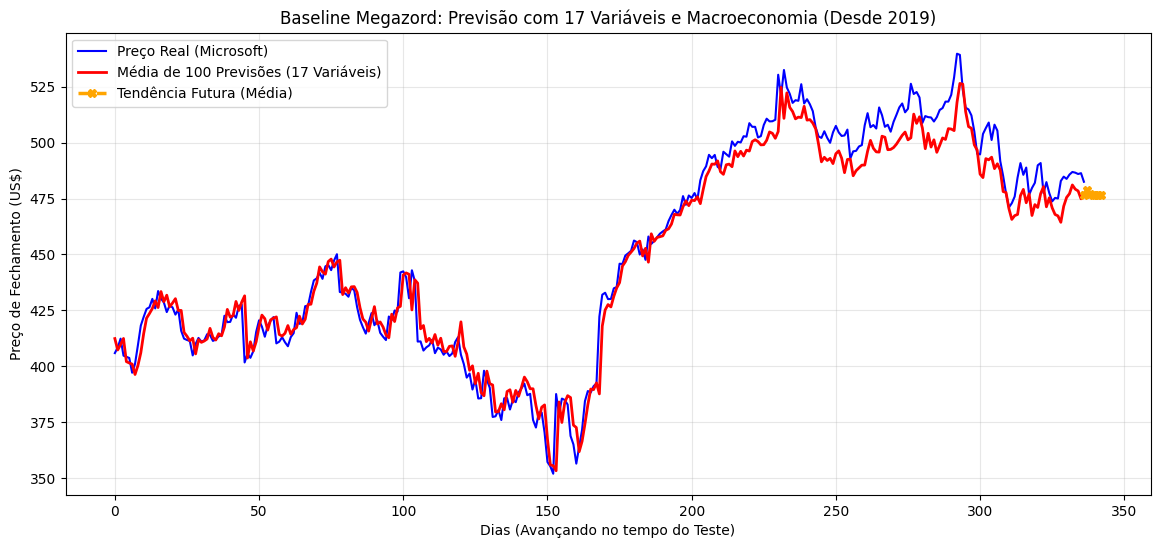


🔮 PREVISÃO FUTURA (7 DIAS) - MEGAZORD:
Dia 1: US$ 478.93
Dia 2: US$ 476.88
Dia 3: US$ 476.64
Dia 4: US$ 476.53
Dia 5: US$ 476.52
Dia 6: US$ 476.54
Dia 7: US$ 476.56


In [ ]:
import matplotlib.pyplot as plt

# =================================================================
# GRÁFICO DO BASELINE (MEGAZORD)
# =================================================================
plt.figure(figsize=(14, 6))

# Plotando os dados de teste (Passado)
plt.plot(reais_em_dolar, label='Preço Real (Microsoft)', color='blue', linewidth=1.5)
plt.plot(media_previsoes_teste, label='Média de 100 Previsões (17 Variáveis)', color='red', linestyle='-', linewidth=2)

# Emendando a Previsão Futura
ultimo_dia_teste = len(reais_em_dolar) - 1
eixo_x_futuro = range(ultimo_dia_teste, ultimo_dia_teste + 7)
linha_futura_conectada = [media_previsoes_teste[-1]] + list(media_previsoes_futuro[:-1])

plt.plot(eixo_x_futuro, linha_futura_conectada, label='Tendência Futura (Média)', color='orange', linestyle='dashed', linewidth=2.5, marker='X')

# Configurações de exibição
plt.title('Baseline Megazord: Previsão com 17 Variáveis e Macroeconomia (Desde 2019)')
plt.xlabel('Dias (Avançando no tempo do Teste)')
plt.ylabel('Preço de Fechamento (US$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Imprimindo os valores da linha laranja
print("\n🔮 PREVISÃO FUTURA (7 DIAS) - MEGAZORD:")
for i, preco in enumerate(media_previsoes_futuro, 1):
    print(f"Dia {i}: US$ {preco:.2f}")

🔥 Iniciando a Máquina Campeã (Bi-LSTM) na: cuda
📥 Baixando e processando 17 indicadores avançados...

🚀 Iniciando 100 modelos (Teste Isolado: Bi-LSTM com 20 dias)...
✅ Rodada 10/100 concluída.
✅ Rodada 20/100 concluída.
✅ Rodada 30/100 concluída.
✅ Rodada 40/100 concluída.
✅ Rodada 50/100 concluída.
✅ Rodada 60/100 concluída.
✅ Rodada 70/100 concluída.
✅ Rodada 80/100 concluída.
✅ Rodada 90/100 concluída.
✅ Rodada 100/100 concluída.

🏆 TESTE DE ABLAÇÃO: BI-LSTM PURA (Janela de 20 dias) 🏆
MAE  (Erro Médio Absoluto): US$ 5.85
RMSE (Raiz do Erro Quadrático): US$ 7.88
MAPE (Erro Percentual): 1.30%


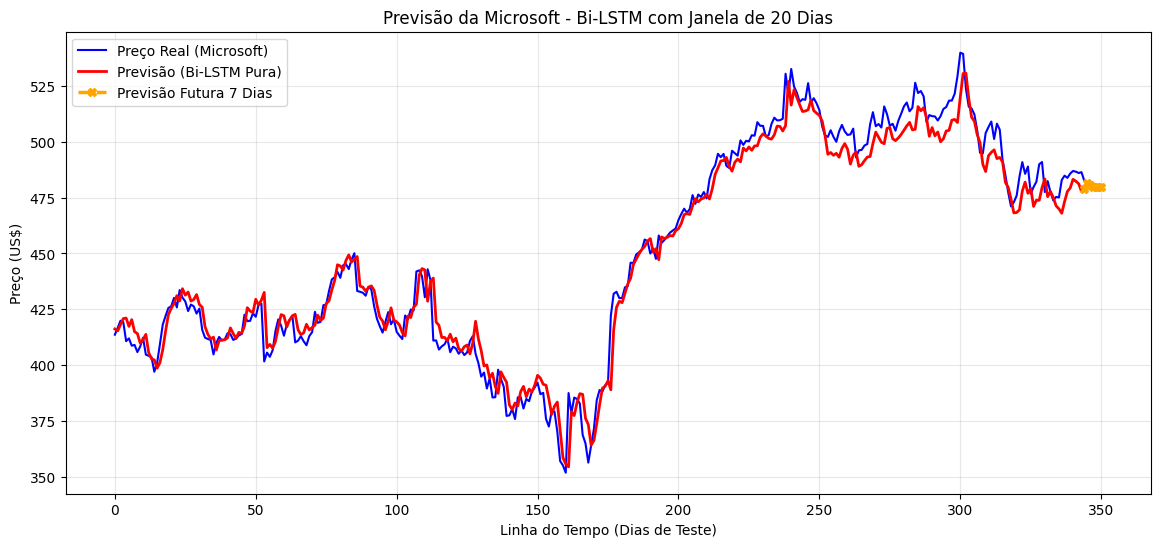

: 

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# =================================================================
# 0. SETUP DA GPU
# =================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Iniciando a Máquina Campeã (Bi-LSTM) na: {device}")

# =================================================================
# PILAR 1: DADOS MEGAZORD (Desde 2019)
# =================================================================
print("📥 Baixando e processando 17 indicadores avançados...")
tickers = ['MSFT', 'GOOGL', 'NVDA', 'META', '^GSPC', '^VIX']
dados = yf.download(tickers, start="2019-01-01", end="2026-01-01", progress=False)

df = pd.DataFrame()
df['MSFT_Close']  = dados['Close']['MSFT']
df['MSFT_Open']   = dados['Open']['MSFT']
df['MSFT_High']   = dados['High']['MSFT']
df['MSFT_Low']    = dados['Low']['MSFT']
df['MSFT_Volume'] = dados['Volume']['MSFT']
df['GOOGL_Close'] = dados['Close']['GOOGL']
df['NVDA_Close']  = dados['Close']['NVDA']
df['META_Close']  = dados['Close']['META']
df['SP500_Close'] = dados['Close']['^GSPC']
df['VIX_Close']   = dados['Close']['^VIX']

df['MSFT_SMA_20'] = df['MSFT_Close'].rolling(window=20).mean()
df['MSFT_EMA_20'] = df['MSFT_Close'].ewm(span=20, adjust=False).mean()

delta = df['MSFT_Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['MSFT_RSI_14'] = 100 - (100 / (1 + rs))

exp1 = df['MSFT_Close'].ewm(span=12, adjust=False).mean()
exp2 = df['MSFT_Close'].ewm(span=26, adjust=False).mean()
df['MSFT_MACD'] = exp1 - exp2
df['MSFT_MACD_Signal'] = df['MSFT_MACD'].ewm(span=9, adjust=False).mean()

std_20 = df['MSFT_Close'].rolling(window=20).std()
df['MSFT_BB_Upper'] = df['MSFT_SMA_20'] + (std_20 * 2)
df['MSFT_BB_Lower'] = df['MSFT_SMA_20'] - (std_20 * 2)

df = df.dropna()
QTD_FEATURES = len(df.columns)

scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(df)

# ---> O NOSSO TESTE DE HOJE: JANELA DE 20 DIAS ÚTEIS (1 MÊS) <---
seq_len = 20 

def criar_sequencias(dados_array, seq_len):
    X, y = [], []
    for i in range(seq_len, len(dados_array)):
        X.append(dados_array[i-seq_len:i])
        y.append(dados_array[i, 0]) # Coluna 0 é a MSFT_Close
    return np.array(X), np.array(y)

X, y = criar_sequencias(dados_normalizados, seq_len)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=32)

matriz_falsa_reais = np.zeros((len(y_test), QTD_FEATURES))
matriz_falsa_reais[:, 0] = y_test
reais_em_dolar = scaler.inverse_transform(matriz_falsa_reais)[:, 0]

# =================================================================
# PILAR 2: A ARQUITETURA CAMPEÃ (Bi-LSTM Sem Dropout e Sem Atenção)
# =================================================================
class Modelo_BiLSTM_IA(nn.Module):
    def __init__(self, input_size, hidden_lstm, hidden_gru, output_size):
        super(Modelo_BiLSTM_IA, self).__init__()
        
        # Bidirecional ativado! Lê o tempo de trás pra frente também.
        self.lstm = nn.LSTM(input_size, hidden_lstm, batch_first=True, bidirectional=True)
        self.gru = nn.GRU(hidden_lstm * 2, hidden_gru, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_gru * 2, output_size)

    def forward(self, x):
        saida_lstm, _ = self.lstm(x)
        saida_gru, _ = self.gru(saida_lstm)
        # Pega a previsão do último dia
        out_ultimo_dia = saida_gru[:, -1, :]
        previsao = self.fc(out_ultimo_dia)
        return previsao

# =================================================================
# PILARES 3 a 5: MEGA TESTE COM OS PARÂMETROS DO OPTUNA
# =================================================================
N_RODADAS = 100 
epocas_por_rodada = 50

# ---> OS NÚMEROS DE OURO QUE NOS DERAM O RECORDE DE 1.38% <---
TESTE_LSTM = 96
TESTE_GRU = 128
TESTE_LR = 0.001

todas_previsoes_teste = []
todas_previsoes_futuro = []

print(f"\n🚀 Iniciando {N_RODADAS} modelos (Teste Isolado: Bi-LSTM com {seq_len} dias)...")

for rodada in range(N_RODADAS):
    modelo_ensemble = Modelo_BiLSTM_IA(
        input_size=QTD_FEATURES, 
        hidden_lstm=TESTE_LSTM, 
        hidden_gru=TESTE_GRU, 
        output_size=1
    ).to(device)
    
    optimizer = optim.Adam(modelo_ensemble.parameters(), lr=TESTE_LR)
    criterion = nn.MSELoss()
    
    # Treino
    modelo_ensemble.train()
    for epoca in range(epocas_por_rodada):
        for pacotes_X, pacotes_y in train_loader:
            pacotes_X, pacotes_y = pacotes_X.to(device), pacotes_y.to(device)
            optimizer.zero_grad()
            previsoes = modelo_ensemble(pacotes_X).squeeze()
            erro = criterion(previsoes, pacotes_y)
            erro.backward()
            optimizer.step()
            
    # Teste
    modelo_ensemble.eval()
    previsoes_modelo = []
    with torch.no_grad():
        for pacotes_X, pacotes_y in test_loader:
            pacotes_X = pacotes_X.to(device)
            chute = modelo_ensemble(pacotes_X)
            previsoes_modelo.extend(chute.cpu().squeeze().tolist())
            
    # Prevendo 7 dias no futuro usando o seq_len dinâmico
    tensor_janela = torch.tensor(dados_normalizados[-seq_len:], dtype=torch.float32).unsqueeze(0)
    previsoes_futuras_normalizadas = []
    with torch.no_grad():
        for i in range(7):
            previsao_msft = modelo_ensemble(tensor_janela.to(device))
            valor_previsto = previsao_msft.cpu().item()
            previsoes_futuras_normalizadas.append(valor_previsto)
            
            novo_dia = tensor_janela[:, -1, :].clone()
            novo_dia[0, 0] = valor_previsto 
            novo_dia = novo_dia.unsqueeze(1)
            tensor_janela = torch.cat((tensor_janela[:, 1:, :], novo_dia), dim=1)

    matriz_teste = np.zeros((len(previsoes_modelo), QTD_FEATURES))
    matriz_teste[:, 0] = previsoes_modelo
    todas_previsoes_teste.append(scaler.inverse_transform(matriz_teste)[:, 0])
    
    matriz_futuro = np.zeros((7, QTD_FEATURES))
    matriz_futuro[:, 0] = previsoes_futuras_normalizadas
    todas_previsoes_futuro.append(scaler.inverse_transform(matriz_futuro)[:, 0])
    
    if (rodada + 1) % 10 == 0:
        print(f"✅ Rodada {rodada+1}/{N_RODADAS} concluída.")

media_previsoes_teste = np.mean(todas_previsoes_teste, axis=0)
media_previsoes_futuro = np.mean(todas_previsoes_futuro, axis=0)

mae_final = mean_absolute_error(reais_em_dolar, media_previsoes_teste)
rmse_final = np.sqrt(mean_squared_error(reais_em_dolar, media_previsoes_teste))
mape_final = np.mean(np.abs((reais_em_dolar - media_previsoes_teste) / (reais_em_dolar + 1e-8))) * 100

print("\n" + "="*60)
print(f"🏆 TESTE DE ABLAÇÃO: BI-LSTM PURA (Janela de {seq_len} dias) 🏆")
print("="*60)
print(f"MAE  (Erro Médio Absoluto): US$ {mae_final:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): US$ {rmse_final:.2f}")
print(f"MAPE (Erro Percentual): {mape_final:.2f}%")
print("="*60)

# =================================================================
# O GRÁFICO DEFINITIVO
# =================================================================
plt.figure(figsize=(14, 6))
plt.plot(reais_em_dolar, label='Preço Real (Microsoft)', color='blue', linewidth=1.5)
plt.plot(media_previsoes_teste, label='Previsão (Bi-LSTM Pura)', color='red', linestyle='-', linewidth=2)

ultimo_dia_teste = len(reais_em_dolar) - 1
eixo_x_futuro = range(ultimo_dia_teste, ultimo_dia_teste + 7)
linha_futura_conectada = [media_previsoes_teste[-1]] + list(media_previsoes_futuro[:-1])
plt.plot(eixo_x_futuro, linha_futura_conectada, label='Previsão Futura 7 Dias', color='orange', linestyle='dashed', linewidth=2.5, marker='X')

plt.title(f'Previsão da Microsoft - Bi-LSTM com Janela de {seq_len} Dias')
plt.xlabel('Linha do Tempo (Dias de Teste)')
plt.ylabel('Preço (US$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

# =================================================================
# 0. SETUP RÁPIDO
# =================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("📥 Baixando dados para a Busca em Grade...")
tickers = ['MSFT', 'GOOGL', 'NVDA', 'META', '^GSPC', '^VIX']
dados = yf.download(tickers, start="2019-01-01", end="2026-01-01", progress=False)

df = pd.DataFrame()
df['MSFT_Close']  = dados['Close']['MSFT']
df['MSFT_Open']   = dados['Open']['MSFT']
df['MSFT_High']   = dados['High']['MSFT']
df['MSFT_Low']    = dados['Low']['MSFT']
df['MSFT_Volume'] = dados['Volume']['MSFT']
df['GOOGL_Close'] = dados['Close']['GOOGL']
df['NVDA_Close']  = dados['Close']['NVDA']
df['META_Close']  = dados['Close']['META']
df['SP500_Close'] = dados['Close']['^GSPC']
df['VIX_Close']   = dados['Close']['^VIX']

df['MSFT_SMA_20'] = df['MSFT_Close'].rolling(window=20).mean()
df['MSFT_EMA_20'] = df['MSFT_Close'].ewm(span=20, adjust=False).mean()
delta = df['MSFT_Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
df['MSFT_RSI_14'] = 100 - (100 / (1 + (gain / loss)))
exp1 = df['MSFT_Close'].ewm(span=12, adjust=False).mean()
exp2 = df['MSFT_Close'].ewm(span=26, adjust=False).mean()
df['MSFT_MACD'] = exp1 - exp2
df['MSFT_MACD_Signal'] = df['MSFT_MACD'].ewm(span=9, adjust=False).mean()
std_20 = df['MSFT_Close'].rolling(window=20).std()
df['MSFT_BB_Upper'] = df['MSFT_SMA_20'] + (std_20 * 2)
df['MSFT_BB_Lower'] = df['MSFT_SMA_20'] - (std_20 * 2)

df = df.dropna()
QTD_FEATURES = len(df.columns)
scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(df)

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class Modelo_BiLSTM_IA(nn.Module):
    def __init__(self, input_size, hidden_lstm, hidden_gru, output_size):
        super(Modelo_BiLSTM_IA, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_lstm, batch_first=True, bidirectional=True)
        self.gru = nn.GRU(hidden_lstm * 2, hidden_gru, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_gru * 2, output_size)

    def forward(self, x):
        saida_lstm, _ = self.lstm(x)
        saida_gru, _ = self.gru(saida_lstm)
        return self.fc(saida_gru[:, -1, :])

# =================================================================
# A GRANDE CAÇADA DA JANELA DE TEMPO
# =================================================================
janelas_para_testar = [10, 15, 20, 25, 30, 45]
resultados_janelas = {}

print("\n🚀 Iniciando a Busca em Grade de Memória Temporal...")

for janela in janelas_para_testar:
    # 1. Recria os dados especificamente para esta janela
    X, y = [], []
    for i in range(janela, len(dados_normalizados)):
        X.append(dados_normalizados[i-janela:i])
        y.append(dados_normalizados[i, 0])
    X, y = np.array(X), np.array(y)
    
    split = int(0.8 * len(X))
    train_loader = DataLoader(TimeSeriesDataset(X[:split], y[:split]), batch_size=32, shuffle=True)
    test_loader = DataLoader(TimeSeriesDataset(X[split:], y[split:]), batch_size=32)
    
    # Prepara os reais para calcular o MAPE corretamente no teste
    matriz_falsa = np.zeros((len(y[split:]), QTD_FEATURES))
    matriz_falsa[:, 0] = y[split:]
    reais = scaler.inverse_transform(matriz_falsa)[:, 0]
    
    todas_previsoes_teste = []
    
    # 2. Treina 15 modelos rápidos com nossos parâmetros campeões
    for rodada in range(15):
        modelo = Modelo_BiLSTM_IA(QTD_FEATURES, 96, 128, 1).to(device)
        optimizer = optim.Adam(modelo.parameters(), lr=0.001)
        criterion = nn.MSELoss()
        
        modelo.train()
        for epoca in range(50):
            for pacotes_X, pacotes_y in train_loader:
                optimizer.zero_grad()
                erro = criterion(modelo(pacotes_X.to(device)).squeeze(), pacotes_y.to(device))
                erro.backward()
                optimizer.step()
                
        modelo.eval()
        previsoes = []
        with torch.no_grad():
            for pacotes_X, _ in test_loader:
                previsoes.extend(modelo(pacotes_X.to(device)).cpu().squeeze().tolist())
                
        matriz_teste = np.zeros((len(previsoes), QTD_FEATURES))
        matriz_teste[:, 0] = previsoes
        todas_previsoes_teste.append(scaler.inverse_transform(matriz_teste)[:, 0])
        
    # 3. Calcula e salva o MAPE médio deste tamanho de janela
    media_previsoes = np.mean(todas_previsoes_teste, axis=0)
    mape = np.mean(np.abs((reais - media_previsoes) / (reais + 1e-8))) * 100
    resultados_janelas[janela] = mape
    print(f"✅ Janela de {janela} dias concluída: MAPE de {mape:.2f}%")

print("\n" + "="*50)
print("🏆 RANKING DOS TAMANHOS DE JANELA (seq_len) 🏆")
print("="*50)
for janela, mape in sorted(resultados_janelas.items(), key=lambda item: item[1]):
    print(f"Janela: {janela} dias --> MAPE: {mape:.2f}%")
print("="*50)

📥 Baixando dados para a Busca em Grade...

🚀 Iniciando a Busca em Grade de Memória Temporal...
✅ Janela de 10 dias concluída: MAPE de 1.35%
✅ Janela de 15 dias concluída: MAPE de 1.28%
✅ Janela de 20 dias concluída: MAPE de 1.34%
✅ Janela de 25 dias concluída: MAPE de 1.35%
✅ Janela de 30 dias concluída: MAPE de 1.27%
✅ Janela de 45 dias concluída: MAPE de 1.32%

🏆 RANKING DOS TAMANHOS DE JANELA (seq_len) 🏆
Janela: 30 dias --> MAPE: 1.27%
Janela: 15 dias --> MAPE: 1.28%
Janela: 45 dias --> MAPE: 1.32%
Janela: 20 dias --> MAPE: 1.34%
Janela: 10 dias --> MAPE: 1.35%
Janela: 25 dias --> MAPE: 1.35%


🔥 Iniciando a Máquina Definitiva Absoluta na: cuda
📥 Baixando 17 indicadores avançados e macroeconomia...

🚀 Iniciando as 100 rodadas finais da Máquina Perfeita...
✅ Rodada 10/100 concluída.
✅ Rodada 20/100 concluída.
✅ Rodada 30/100 concluída.
✅ Rodada 40/100 concluída.
✅ Rodada 50/100 concluída.
✅ Rodada 60/100 concluída.
✅ Rodada 70/100 concluída.
✅ Rodada 80/100 concluída.
✅ Rodada 90/100 concluída.
✅ Rodada 100/100 concluída.

🏆 MODELO FINAL DEFINITIVO: 100 REDES, BI-LSTM, 30 DIAS 🏆
MAE  (Erro Médio Absoluto): US$ 6.36
RMSE (Raiz do Erro Quadrático): US$ 8.44
MAPE (Erro Percentual): 1.40%


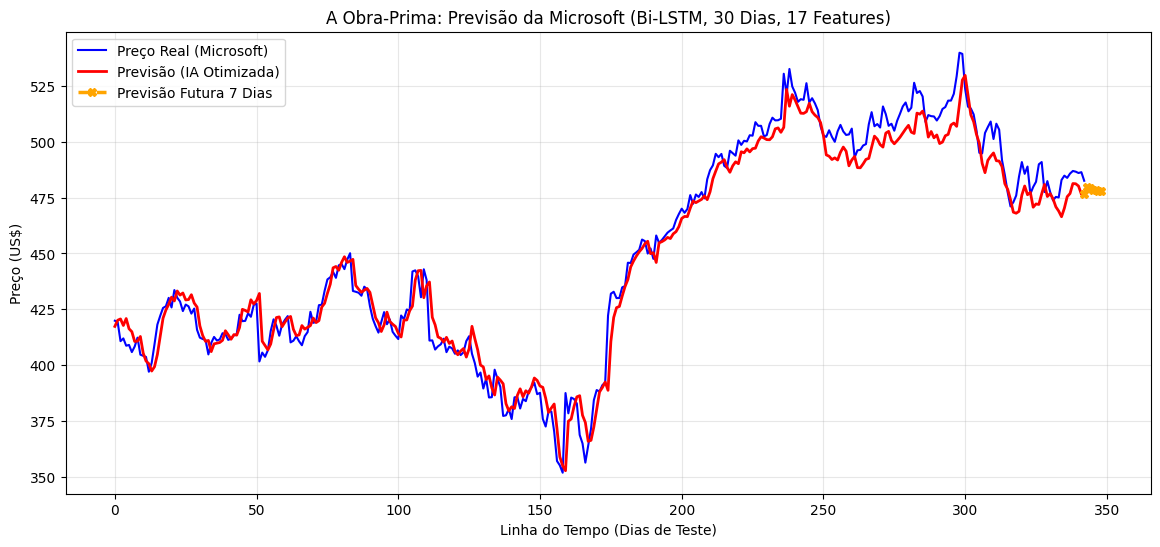

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# =================================================================
# 0. SETUP
# =================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Iniciando a Máquina Definitiva Absoluta na: {device}")

# =================================================================
# PILAR 1: DADOS MEGAZORD (Desde 2019)
# =================================================================
print("📥 Baixando 17 indicadores avançados e macroeconomia...")
tickers = ['MSFT', 'GOOGL', 'NVDA', 'META', '^GSPC', '^VIX']
dados = yf.download(tickers, start="2019-01-01", end="2026-01-01", progress=False)

df = pd.DataFrame()
df['MSFT_Close']  = dados['Close']['MSFT']
df['MSFT_Open']   = dados['Open']['MSFT']
df['MSFT_High']   = dados['High']['MSFT']
df['MSFT_Low']    = dados['Low']['MSFT']
df['MSFT_Volume'] = dados['Volume']['MSFT']
df['GOOGL_Close'] = dados['Close']['GOOGL']
df['NVDA_Close']  = dados['Close']['NVDA']
df['META_Close']  = dados['Close']['META']
df['SP500_Close'] = dados['Close']['^GSPC']
df['VIX_Close']   = dados['Close']['^VIX']

df['MSFT_SMA_20'] = df['MSFT_Close'].rolling(window=20).mean()
df['MSFT_EMA_20'] = df['MSFT_Close'].ewm(span=20, adjust=False).mean()

delta = df['MSFT_Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['MSFT_RSI_14'] = 100 - (100 / (1 + rs))

exp1 = df['MSFT_Close'].ewm(span=12, adjust=False).mean()
exp2 = df['MSFT_Close'].ewm(span=26, adjust=False).mean()
df['MSFT_MACD'] = exp1 - exp2
df['MSFT_MACD_Signal'] = df['MSFT_MACD'].ewm(span=9, adjust=False).mean()

std_20 = df['MSFT_Close'].rolling(window=20).std()
df['MSFT_BB_Upper'] = df['MSFT_SMA_20'] + (std_20 * 2)
df['MSFT_BB_Lower'] = df['MSFT_SMA_20'] - (std_20 * 2)

df = df.dropna()
QTD_FEATURES = len(df.columns)

scaler = MinMaxScaler()
dados_normalizados = scaler.fit_transform(df)

# ---> A NOSSA JANELA DE OURO DESCOBERTA <---
seq_len = 30 

def criar_sequencias(dados_array, seq_len):
    X, y = [], []
    for i in range(seq_len, len(dados_array)):
        X.append(dados_array[i-seq_len:i])
        y.append(dados_array[i, 0])
    return np.array(X), np.array(y)

X, y = criar_sequencias(dados_normalizados, seq_len)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=32)

matriz_falsa_reais = np.zeros((len(y_test), QTD_FEATURES))
matriz_falsa_reais[:, 0] = y_test
reais_em_dolar = scaler.inverse_transform(matriz_falsa_reais)[:, 0]

# =================================================================
# PILAR 2: A ARQUITETURA CAMPEÃ (Bi-LSTM Pura)
# =================================================================
class Modelo_BiLSTM_IA(nn.Module):
    def __init__(self, input_size, hidden_lstm, hidden_gru, output_size):
        super(Modelo_BiLSTM_IA, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_lstm, batch_first=True, bidirectional=True)
        self.gru = nn.GRU(hidden_lstm * 2, hidden_gru, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_gru * 2, output_size)

    def forward(self, x):
        saida_lstm, _ = self.lstm(x)
        saida_gru, _ = self.gru(saida_lstm)
        return self.fc(saida_gru[:, -1, :])

# =================================================================
# PILARES 3 a 5: O MEGA TESTE FINAL
# =================================================================
N_RODADAS = 100 
epocas_por_rodada = 50

# ---> OS HIPERPARÂMETROS DE OURO DO OPTUNA <---
TESTE_LSTM = 96
TESTE_GRU = 128
TESTE_LR = 0.001

todas_previsoes_teste = []
todas_previsoes_futuro = []

print(f"\n🚀 Iniciando as {N_RODADAS} rodadas finais da Máquina Perfeita...")

for rodada in range(N_RODADAS):
    modelo_ensemble = Modelo_BiLSTM_IA(
        input_size=QTD_FEATURES, 
        hidden_lstm=TESTE_LSTM, 
        hidden_gru=TESTE_GRU, 
        output_size=1
    ).to(device)
    
    optimizer = optim.Adam(modelo_ensemble.parameters(), lr=TESTE_LR)
    
    # 🌟 NOVIDADE: Instalando o Freio (Scheduler)
    # A cada 15 épocas, ele corta a taxa de aprendizado pela metade (gamma=0.5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)
    
    criterion = nn.MSELoss()
    
    modelo_ensemble.train()
    for epoca in range(epocas_por_rodada):
        for pacotes_X, pacotes_y in train_loader:
            pacotes_X, pacotes_y = pacotes_X.to(device), pacotes_y.to(device)
            optimizer.zero_grad()
            previsoes = modelo_ensemble(pacotes_X).squeeze()
            erro = criterion(previsoes, pacotes_y)
            erro.backward()
            optimizer.step()
            
        # 🌟 NOVIDADE: Avisa o freio que uma época passou
        scheduler.step()
            
    modelo_ensemble.eval()
    previsoes_modelo = []
    with torch.no_grad():
        for pacotes_X, pacotes_y in test_loader:
            pacotes_X = pacotes_X.to(device)
            chute = modelo_ensemble(pacotes_X)
            previsoes_modelo.extend(chute.cpu().squeeze().tolist())
            
    tensor_janela = torch.tensor(dados_normalizados[-seq_len:], dtype=torch.float32).unsqueeze(0)
    previsoes_futuras_normalizadas = []
    with torch.no_grad():
        for i in range(7):
            previsao_msft = modelo_ensemble(tensor_janela.to(device))
            valor_previsto = previsao_msft.cpu().item()
            previsoes_futuras_normalizadas.append(valor_previsto)
            
            novo_dia = tensor_janela[:, -1, :].clone()
            novo_dia[0, 0] = valor_previsto 
            novo_dia = novo_dia.unsqueeze(1)
            tensor_janela = torch.cat((tensor_janela[:, 1:, :], novo_dia), dim=1)

    matriz_teste = np.zeros((len(previsoes_modelo), QTD_FEATURES))
    matriz_teste[:, 0] = previsoes_modelo
    todas_previsoes_teste.append(scaler.inverse_transform(matriz_teste)[:, 0])
    
    matriz_futuro = np.zeros((7, QTD_FEATURES))
    matriz_futuro[:, 0] = previsoes_futuras_normalizadas
    todas_previsoes_futuro.append(scaler.inverse_transform(matriz_futuro)[:, 0])
    
    if (rodada + 1) % 10 == 0:
        print(f"✅ Rodada {rodada+1}/{N_RODADAS} concluída.")

media_previsoes_teste = np.mean(todas_previsoes_teste, axis=0)
media_previsoes_futuro = np.mean(todas_previsoes_futuro, axis=0)

mae_final = mean_absolute_error(reais_em_dolar, media_previsoes_teste)
rmse_final = np.sqrt(mean_squared_error(reais_em_dolar, media_previsoes_teste))
mape_final = np.mean(np.abs((reais_em_dolar - media_previsoes_teste) / (reais_em_dolar + 1e-8))) * 100

print("\n" + "="*60)
print(f"🏆 MODELO FINAL DEFINITIVO: 100 REDES, BI-LSTM, 30 DIAS 🏆")
print("="*60)
print(f"MAE  (Erro Médio Absoluto): US$ {mae_final:.2f}")
print(f"RMSE (Raiz do Erro Quadrático): US$ {rmse_final:.2f}")
print(f"MAPE (Erro Percentual): {mape_final:.2f}%")
print("="*60)

# =================================================================
# O GRÁFICO DEFINITIVO
# =================================================================
plt.figure(figsize=(14, 6))
plt.plot(reais_em_dolar, label='Preço Real (Microsoft)', color='blue', linewidth=1.5)
plt.plot(media_previsoes_teste, label='Previsão (IA Otimizada)', color='red', linestyle='-', linewidth=2)

ultimo_dia_teste = len(reais_em_dolar) - 1
eixo_x_futuro = range(ultimo_dia_teste, ultimo_dia_teste + 7)
linha_futura_conectada = [media_previsoes_teste[-1]] + list(media_previsoes_futuro[:-1])
plt.plot(eixo_x_futuro, linha_futura_conectada, label='Previsão Futura 7 Dias', color='orange', linestyle='dashed', linewidth=2.5, marker='X')

plt.title(f'A Obra-Prima: Previsão da Microsoft (Bi-LSTM, 30 Dias, 17 Features)')
plt.xlabel('Linha do Tempo (Dias de Teste)')
plt.ylabel('Preço (US$)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()